# Multiplex Classification Comparison

| | **Dataset 1 (DS1)** | **Dataset 2 (DS2)** |
|---|---|---|
| Source | `LAB_Multiplex/02_ACA_qdPCR_balanced` | `LAB_DDM_paper/12_ACA_qdPCR_multiplex_balanced` |
| Approach | Multilabel (binary per target) | Multiclass (7 consolidated classes) |

**Metrics** (all ∈ [0, 1], higher = better)

| Metric | Formula |
|---|---|
| Exact accuracy | all labels match |
| Hamming score | element-wise label accuracy (1 − hamming_loss) |
| Strict Hamming | 0 if any false positive; else label accuracy |
| Jaccard score | \|y ∩ ŷ\| / \|y ∪ ŷ\| per sample, averaged |

**Sections:** Baselines · A (All families, DS1) · C (CNN+GRU deep dive, DS1)

In [1]:
import json, sys, math
from pathlib import Path

import joblib
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_ROOT_ML  = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_Multiplex')
DATA_ROOT_DDM = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper')
DS1_NAME = '02_ACA_qdPCR_balanced'
DS2_NAME = '12_ACA_qdPCR_multiplex_balanced'

TARGET_NAMES = ['KPC', 'NDM', 'VIM']
BASE_COLORS  = {'KPC': '#E64A19', 'NDM': '#1565C0', 'VIM': '#2E7D32'}
LABEL_REMAP  = {'KPC_NDM': 'NDM_KPC', 'KPC_VIM': 'VIM_KPC', 'KPC_NDM_VIM': 'NDM_VIM_KPC'}
LABEL_ORDER  = ['NDM', 'VIM', 'KPC', 'NDM_VIM', 'NDM_KPC', 'VIM_KPC', 'NDM_VIM_KPC']

CM_LABELS = LABEL_ORDER + ['empty']
CM_DISP   = [l.replace('_', '+') if l != 'empty' else '∅' for l in CM_LABELS]

DS2_BIN_MAP = np.array([
    [1,0,0],[0,1,0],[1,1,0],[0,0,1],[1,0,1],[0,1,1],[1,1,1]
])

FAMILY_COLORS = {
    'CNN':'#1565C0','GRU':'#2E7D32','Transformer':'#6A1B9A',
    'CNN+GRU':'#E64A19','CNN+Trans':'#00838F','SrcSep':'#6A1B9A',
}
GRU_GROUP_COLORS = {
    'Base':'#E64A19','CRF-MRF':'#BF360C','CRF-Chain':'#F57F17',
    'CAttn':'#880E4F','CAttn-v2':'#AD1457',
}
DS_COLORS = {'DS1 (multilabel)':'#E64A19','DS2 (multiclass)':'#1565C0'}

In [2]:
d1_main  = joblib.load(DATA_ROOT_ML / DS1_NAME / 'classification_performances_ml_10fold.joblib')[None]
d1_crf   = joblib.load(DATA_ROOT_ML / DS1_NAME / 'classification_performances_ml_crf_10fold.joblib')[None]
d1_cattn = joblib.load(DATA_ROOT_ML / DS1_NAME / 'classification_performances_ml_cattn_v2_10fold.joblib')[None]
d1_xattn = joblib.load(DATA_ROOT_ML / DS1_NAME / 'classification_performances_ml_cross_attn_10fold.joblib')[None]
d1_serial_ss = joblib.load(DATA_ROOT_ML / DS1_NAME / 'classification_performances_ml_source_sep_serial_10fold.joblib')[None]

d2_raw = joblib.load(DATA_ROOT_DDM / DS2_NAME / 'classification_performances_10fold.joblib')
d2 = d2_raw['Ori Curves']['Native'][None]

y_trues_d1 = [np.array(yt) for yt in d1_main['y_trues_']]
y_trues_d2 = [DS2_BIN_MAP[np.array(yt)] for yt in d2['y_trues_']]

print(f'DS1: {len(y_trues_d1)} folds, N/fold ≈ {len(y_trues_d1[0])}')
print(f'DS2: {len(y_trues_d2)} folds, N/fold ≈ {len(y_trues_d2[0])}')

DS1: 5 folds, N/fold ≈ 2077
DS2: 5 folds, N/fold ≈ 2077


In [3]:
def exact_acc(y_true, y_pred):
    return float(np.mean(np.all(y_true == y_pred, axis=1)))

def hamming_sc(y_true, y_pred):
    return float(np.mean(y_true == y_pred))

def strict_hamming_sc(y_true, y_pred):
    fp = np.sum((1 - y_true) * y_pred, axis=1)
    return float(np.where(fp > 0, 0.0, np.mean(y_true == y_pred, axis=1)).mean())

def jaccard_sc(y_true, y_pred):
    inter = np.sum(y_true & y_pred, axis=1).astype(float)
    union = np.sum(y_true | y_pred, axis=1).astype(float)
    return float(np.mean(np.where(union > 0, inter / union, 1.0)))

METRICS = [
    ('exact',   'Exact Accuracy',       exact_acc),
    ('hamming', 'Hamming Score',        hamming_sc),
    ('strict',  'Strict Hamming',       strict_hamming_sc),
    ('jaccard', 'Jaccard Score',        jaccard_sc),
]

def compute_metrics(y_trues_bin, y_preds_bin):
    out = {}
    for name, _, fn in METRICS:
        vals = [fn(yt, yp) for yt, yp in zip(y_trues_bin, y_preds_bin)]
        out[name] = (float(np.mean(vals)), float(np.std(vals)))
    return out


In [4]:
DS1_ALL_FAMILIES = [
    ('CNN       SC0','CNN',        d1_main,'cnn_'),
    ('CNN       SC1','CNN',        d1_main,'cnn_supcon_'),
    ('GRU       SC0','GRU',        d1_main,'gru_'),
    ('GRU       SC1','GRU',        d1_main,'gru_supcon_'),
    ('Trans     SC0','Transformer',d1_main,'transformer_'),
    ('Trans     SC1','Transformer',d1_main,'transformer_supcon_'),
    ('CNN+GRU   SC0','CNN+GRU',   d1_main,'cnn_gru_dual_'),
    ('CNN+GRU   SC1','CNN+GRU',   d1_main,'cnn_gru_dual_supcon_'),
    ('CNN+GRU   SC2','CNN+GRU',   d1_main,'cnn_gru_dual_supcon2_'),
    ('CNN+GRU   SC3','CNN+GRU',   d1_main,'cnn_gru_dual_supcon3_'),
    ('CNN+Trans SC0','CNN+Trans', d1_main,'cnn_trans_dual_'),
    ('CNN+Trans SC1','CNN+Trans', d1_main,'cnn_trans_dual_supcon_'),
    ('CNN+Trans SC2','CNN+Trans', d1_main,'cnn_trans_dual_supcon2_'),
    ('CNN+Trans SC3','CNN+Trans', d1_main,'cnn_trans_dual_supcon3_'),
    ('SrcSep  avg',  'SrcSep',   d1_serial_ss,'serial_source_sep_active_avg_p2_'),
]
DS1_GRU_DEEP = [
    ('Base    SC0','Base',    d1_main, 'cnn_gru_dual_'),
    ('Base    SC1','Base',    d1_main, 'cnn_gru_dual_supcon_'),
    ('Base    SC2','Base',    d1_main, 'cnn_gru_dual_supcon2_'),
    ('Base    SC3','Base',    d1_main, 'cnn_gru_dual_supcon3_'),
    ('CRF-MRF SC0','CRF-MRF',d1_crf,  'cnn_gru_dual_crf_mrf_'),
    ('CRF-MRF SC1','CRF-MRF',d1_crf,  'cnn_gru_dual_crf_mrf_supcon_'),
    ('CRF-MRF SC2','CRF-MRF',d1_crf,  'cnn_gru_dual_crf_mrf_supcon2_'),
    ('CRF-MRF SC3','CRF-MRF',d1_crf,  'cnn_gru_dual_crf_mrf_supcon3_'),
    ('CRF-Chain SC0','CRF-Chain',d1_crf,'cnn_gru_dual_crf_chain_'),
    ('CRF-Chain SC1','CRF-Chain',d1_crf,'cnn_gru_dual_crf_chain_supcon_'),
    ('CRF-Chain SC2','CRF-Chain',d1_crf,'cnn_gru_dual_crf_chain_supcon2_'),
    ('CRF-Chain SC3','CRF-Chain',d1_crf,'cnn_gru_dual_crf_chain_supcon3_'),
    ('CAttn   SC0','CAttn',  d1_xattn,'cnn_gru_dual_cross_attn_'),
    ('CAttn   SC1','CAttn',  d1_xattn,'cnn_gru_dual_cross_attn_supcon_'),
    ('CAttn   SC2','CAttn',  d1_xattn,'cnn_gru_dual_cross_attn_supcon2_'),
    ('CAttn   SC3','CAttn',  d1_xattn,'cnn_gru_dual_cross_attn_supcon3_'),
    ('CAttn-v2 SC0','CAttn-v2',d1_cattn,'cnn_gru_dual_cross_attn_v2_'),
    ('CAttn-v2 SC1','CAttn-v2',d1_cattn,'cnn_gru_dual_cross_attn_v2_supcon_'),
]

def _load(label_family_dct_sfx_list, y_trues):
    res = {}
    for lbl, fam, dct, sfx in label_family_dct_sfx_list:
        pk = f'y_preds_{sfx}'
        if pk in dct:
            preds = [np.array(yp) for yp in dct[pk]]
            res[lbl] = {'family': fam, 'metrics': compute_metrics(y_trues, preds)}
    return res

results_a = _load(DS1_ALL_FAMILIES, y_trues_d1)
results_c = _load(DS1_GRU_DEEP,     y_trues_d1)

print(f'A:{len(results_a)}  C:{len(results_c)}')

A:15  C:18


In [5]:
# ─── shared inner ─────────────────────────────────────────────────────────────
def _add_bar_labels(ax, bars, vals, stds, fontsize=7.5, x_max=1.22):
    for bar, v, s in zip(bars, vals, stds):
        if np.isnan(v): continue
        text = f'{v:.2f}' if s == 0 else f'{v:.2f}±{s:.2f}'
        ax.text(min(bar.get_width() + 0.009, x_max - 0.06),
                bar.get_y() + bar.get_height() / 2,
                text, va='center', ha='left', fontsize=fontsize)

def _style_hbar_ax(ax, labels, xlabel, x_max=1.22, show_yticks=True, fontsize=9):
    y_pos = np.arange(len(labels))
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels if show_yticks else ['']*len(labels), fontsize=fontsize)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_xlim(0, x_max)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.4)


# ─── public plot functions ────────────────────────────────────────────────────
def plot_metric_bars(results, title, color_fn, legend_handles=None, row_h=0.55):
    """One subplot per metric; horizontal bars, one row per model."""
    labels = list(results.keys())
    n = len(labels)
    y_pos = np.arange(n)
    fig, axes = plt.subplots(1, len(METRICS),
                             figsize=(7*len(METRICS), max(4, n*row_h)),
                             constrained_layout=True)
    for ax_i, (ax, (mname, mlabel, _)) in enumerate(zip(axes, METRICS)):
        vals   = [results[l]['metrics'][mname][0] for l in labels]
        stds   = [results[l]['metrics'][mname][1] for l in labels]
        colors = [color_fn(l) for l in labels]
        bars   = ax.barh(y_pos, vals, xerr=stds, color=colors, alpha=0.82,
                         edgecolor='white', linewidth=0.5, capsize=3)
        _add_bar_labels(ax, bars, vals, stds)
        _style_hbar_ax(ax, labels, mlabel, show_yticks=(ax_i == 0))
        ax.set_title(mlabel, fontsize=11, fontweight='bold')
    if legend_handles:
        axes[-1].legend(handles=legend_handles, loc='lower right',
                        fontsize=9, framealpha=0.9, edgecolor='#BDBDBD')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.show()


def plot_cross_dataset_bars(compare_rows, title):
    """Multi-model metric comparison. compare_rows = [(label, metrics_dict, color, hatch)]."""
    n = len(compare_rows)
    fig, axes = plt.subplots(1, len(METRICS),
                             figsize=(7*len(METRICS), max(3, n*0.9)),
                             constrained_layout=True)
    for ax_i, (ax, (mname, mlabel, _)) in enumerate(zip(axes, METRICS)):
        for i, (lbl, met, color, hatch) in enumerate(compare_rows):
            mean, std = met[mname]
            ax.barh(i, mean, xerr=(std if std > 0 else None), height=0.5,
                    color=color, hatch=hatch, alpha=0.85,
                    edgecolor='white', linewidth=0.5, capsize=3)
            text = f'{mean*100:.2f}' if std == 0 else f'{mean*100:.2f}±{std*100:.2f}'
            ax.text(min(mean + 0.009, 1.16), i, text, va='center', ha='left', fontsize=9.5)
        _style_hbar_ax(ax, [r[0] for r in compare_rows], mlabel, show_yticks=(ax_i == 0))
        ax.set_title(mlabel, fontsize=11, fontweight='bold')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.show()


def plot_confusion_matrices(cms_data, sup_title):
    """Row-normalised CMs. cms_data = list of (title_str, cm_array)."""
    n_lbl = len(CM_LABELS)
    fig, axes = plt.subplots(1, len(cms_data), figsize=(7*len(cms_data), 7),
                             constrained_layout=True)
    if len(cms_data) == 1: axes = [axes]
    im = None
    for ax, (title, cm) in zip(axes, cms_data):
        rs     = cm.sum(axis=1, keepdims=True)
        cm_n   = np.where(rs > 0, cm / rs, 0.0)
        acc    = np.trace(cm) / cm.sum()
        im     = ax.imshow(cm_n, cmap='Blues', vmin=0, vmax=1, aspect='auto')
        for r in range(n_lbl):
            for c in range(n_lbl):
                if cm[r,c] == 0: continue
                fg = 'white' if cm_n[r,c] > 0.55 else 'black'
                ax.text(c, r, f'{cm_n[r,c]*100:.1f}%\n({cm[r,c]})',
                        ha='center', va='center', fontsize=12, color=fg)
        ax.set_xticks(range(n_lbl)); ax.set_xticklabels(CM_DISP, rotation=45, ha='right', fontsize=12)
        ax.set_yticks(range(n_lbl)); ax.set_yticklabels(CM_DISP, fontsize=12)
        ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('True', fontsize=12)
        ax.set_title(f'{title}\nAcc={acc:.3f}', fontsize=14, fontweight='bold')
    if im: plt.colorbar(im, ax=axes[-1], label='Row-normalised fraction', shrink=0.7)
    fig.suptitle(sup_title, fontsize=12, fontweight='bold')
    plt.show()


def plot_per_combo(compare_rows, title):
    """Per-combination exact accuracy. compare_rows = [(label, acc_dict, color, hatch)]."""
    all_keys = set(k for _, d, _, _ in compare_rows for k in d)
    combos   = [l for l in LABEL_ORDER if l in all_keys]
    n_rows, bar_h = len(compare_rows), 0.35
    y_pos = np.arange(len(combos))
    fig, ax = plt.subplots(figsize=(10, max(4, len(combos)*0.65)), constrained_layout=True)
    for i, (lbl, acc_dict, color, hatch) in enumerate(compare_rows):
        offset = (i - n_rows/2 + 0.5) * bar_h
        vals = [acc_dict.get(c, np.nan) for c in combos]
        bars = ax.barh(y_pos + offset, vals, height=bar_h, color=color, hatch=hatch,
                       alpha=0.85, edgecolor='white', linewidth=0.5, label=lbl)
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                ax.text(min(bar.get_width()+0.008, 1.18),
                        bar.get_y()+bar.get_height()/2,
                        f'{v:.2f}', va='center', ha='left', fontsize=8.5)
    ax.set_yticks(y_pos); ax.set_yticklabels(combos, fontsize=10)
    ax.set_xlabel('Exact Accuracy (per combination)', fontsize=10)
    ax.set_xlim(0, 1.20)
    ax.legend(fontsize=9, framealpha=0.9, edgecolor='#BDBDBD')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.show()


# ─── confusion matrix builder ─────────────────────────────────────────────────
def _bin_to_cm_label(vec):
    targets = [TARGET_NAMES[i] for i, v in enumerate(vec) if v == 1]
    if not targets: return 'empty'
    raw = '_'.join(sorted(targets, key=['KPC','NDM','VIM'].index))
    return LABEL_REMAP.get(raw, raw)

def build_cm(y_true_bin, y_pred_bin):
    idx = {l: i for i, l in enumerate(CM_LABELS)}
    cm  = np.zeros((len(CM_LABELS), len(CM_LABELS)), dtype=int)
    for yt, yp in zip(y_true_bin, y_pred_bin):
        cm[idx[_bin_to_cm_label(yt)]][idx[_bin_to_cm_label(yp)]] += 1
    return cm

def per_combo_acc(y_trues_bin, y_preds_bin):
    """Returns {label: exact_fraction} using LABEL_ORDER / LABEL_REMAP."""
    from collections import Counter
    correct, total = Counter(), Counter()
    for yt, yp in zip(y_trues_bin, y_preds_bin):
        for t_row, p_row in zip(yt, yp):
            lbl = _bin_to_cm_label(t_row)
            total[lbl]   += 1
            correct[lbl] += int(np.all(t_row == p_row))
    return {l: correct[l]/total[l] for l in LABEL_ORDER if total[l] > 0}

print('Plotting helpers loaded.')

Plotting helpers loaded.


## Baselines & 5-Model Comparison

`baseline_performance.json` provides two reference baselines on the full dataset (N=10,383):

- **MCA** (Multi-Class Assignment): rule-based; sometimes predicts multi-target combinations
- **ACA** (Area/Concentration Analysis): assigns only single-target labels

All three plots below compare the same five entries:
MCA · ACA · CNN+GRU SC0 (DS1) · SrcSep active avg (DS1) · CNN+GRU SC2 (DS2)

MCA: exact=0.4071±0.0000
ACA: exact=0.3810±0.0000
CNN+GRU SC0 (DS1): exact=0.6776±0.0133
serial_source_sep_active_avg_p2 (DS1): exact=0.6296±0.0077
CNN+GRU SC2 (DS2): exact=0.7604±0.0173


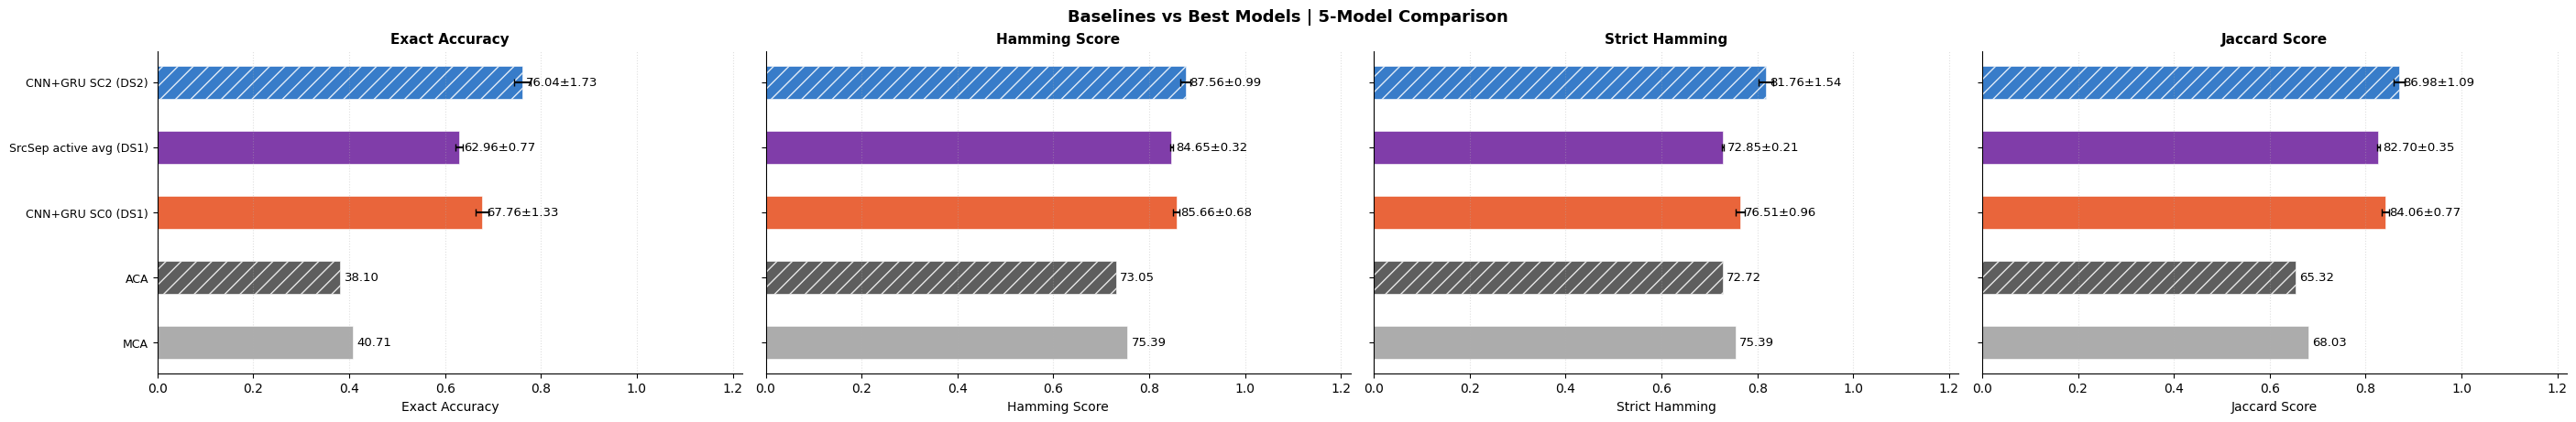

In [6]:
import json

with open(DATA_ROOT_ML / DS1_NAME / 'baseline_performance.json') as f:
    bl_data = json.load(f)

def _label_to_bin(s):
    vec = np.zeros(3, dtype=int)
    for p in s.split('+'): vec[{'KPC':0,'NDM':1,'VIM':2}[p]] = 1
    return vec

def _build_bl_arrays(data, bl_type):
    yt, yp = [], []
    for e in data:
        if e['type'] != bl_type or e['count'] == 0: continue
        yt.extend([_label_to_bin(e['real'])]             * e['count'])
        yp.extend([_label_to_bin(e['predicted_class'])]  * e['count'])
    return np.array(yt), np.array(yp)

yt_mca, yp_mca = _build_bl_arrays(bl_data, 'MCA')
yt_aca, yp_aca = _build_bl_arrays(bl_data, 'ACA')

metrics_mca = {name: (fn(yt_mca, yp_mca), 0.0) for name, _, fn in METRICS}
metrics_aca = {name: (fn(yt_aca, yp_aca), 0.0) for name, _, fn in METRICS}

# CNN+GRU SC0 (DS1)
cgd_sc0_metrics = results_a['CNN+GRU   SC0']['metrics']

# Serial source-sep active avg (DS1)
SS_KEY = 'serial_source_sep_active_avg_p2'
_ss_preds = [np.array(yp) for yp in d1_serial_ss[f'y_preds_{SS_KEY}_']]
ss_metrics = compute_metrics(y_trues_d1, _ss_preds)

# DS2 CNN+GRU SC2
_ds2_sc2_preds = [DS2_BIN_MAP[np.array(yp)] for yp in d2['y_preds_AC_cnn_gru_dual_supcon2_']]
ds2_sc2_metrics = compute_metrics(y_trues_d2, _ds2_sc2_preds)

for label, met in [('MCA', metrics_mca), ('ACA', metrics_aca),
                    ('CNN+GRU SC0 (DS1)', cgd_sc0_metrics),
                    (f'{SS_KEY} (DS1)', ss_metrics),
                    ('CNN+GRU SC2 (DS2)', ds2_sc2_metrics)]:
    m, s = met['exact']
    print(f'{label}: exact={m:.4f}±{s:.4f}')

compare_rows = [
    ('MCA',                      metrics_mca,     '#9E9E9E', ''),
    ('ACA',                      metrics_aca,     '#424242', '//'),
    ('CNN+GRU SC0 (DS1)',        cgd_sc0_metrics, '#E64A19', ''),
    ('SrcSep active avg (DS1)',  ss_metrics,      '#6A1B9A', ''),
    ('CNN+GRU SC2 (DS2)',        ds2_sc2_metrics, '#1565C0', '//'),
]
plot_cross_dataset_bars(compare_rows, 'Baselines vs Best Models | 5-Model Comparison')

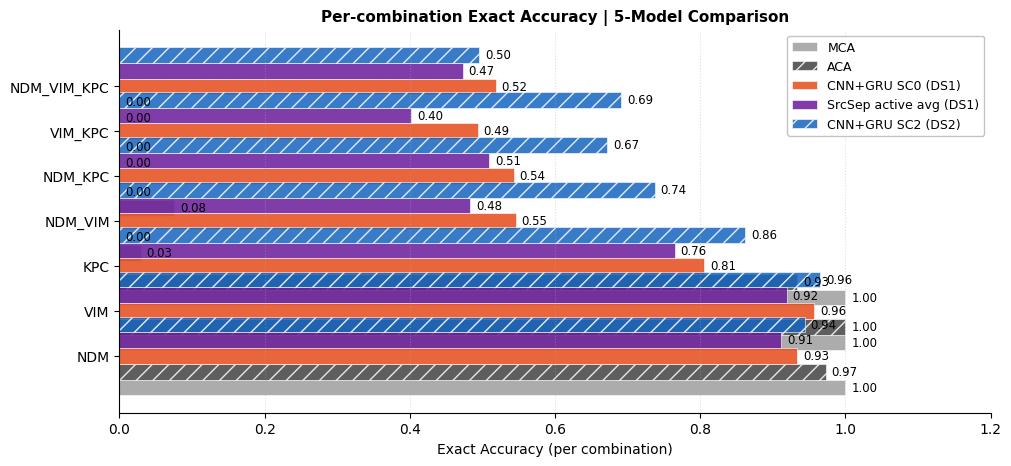

In [7]:
acc_mca  = per_combo_acc([yt_mca],      [yp_mca])
acc_aca  = per_combo_acc([yt_aca],      [yp_aca])
acc_cgd  = per_combo_acc(y_trues_d1,   [np.array(yp) for yp in d1_main['y_preds_cnn_gru_dual_']])
acc_ss   = per_combo_acc(y_trues_d1,   [np.array(yp) for yp in d1_serial_ss[f'y_preds_{SS_KEY}_']])
acc_ds2  = per_combo_acc(y_trues_d2,   [DS2_BIN_MAP[np.array(yp)] for yp in d2['y_preds_AC_cnn_gru_dual_supcon2_']])

plot_per_combo(
    [('MCA',                      acc_mca,  '#9E9E9E', ''),
     ('ACA',                      acc_aca,  '#424242', '//'),
     ('CNN+GRU SC0 (DS1)',        acc_cgd,  '#E64A19', ''),
     ('SrcSep active avg (DS1)',  acc_ss,   '#6A1B9A', ''),
     ('CNN+GRU SC2 (DS2)',        acc_ds2,  '#1565C0', '//')],
    'Per-combination Exact Accuracy | 5-Model Comparison',
)

/tmp/ipykernel_1737002/3069166293.py:74: RuntimeWarning: invalid value encountered in divide
  cm_n   = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_1737002/3069166293.py:74: RuntimeWarning: invalid value encountered in divide
  cm_n   = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_1737002/3069166293.py:74: RuntimeWarning: invalid value encountered in divide
  cm_n   = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_1737002/3069166293.py:74: RuntimeWarning: invalid value encountered in divide
  cm_n   = np.where(rs > 0, cm / rs, 0.0)
/tmp/ipykernel_1737002/3069166293.py:74: RuntimeWarning: invalid value encountered in divide
  cm_n   = np.where(rs > 0, cm / rs, 0.0)


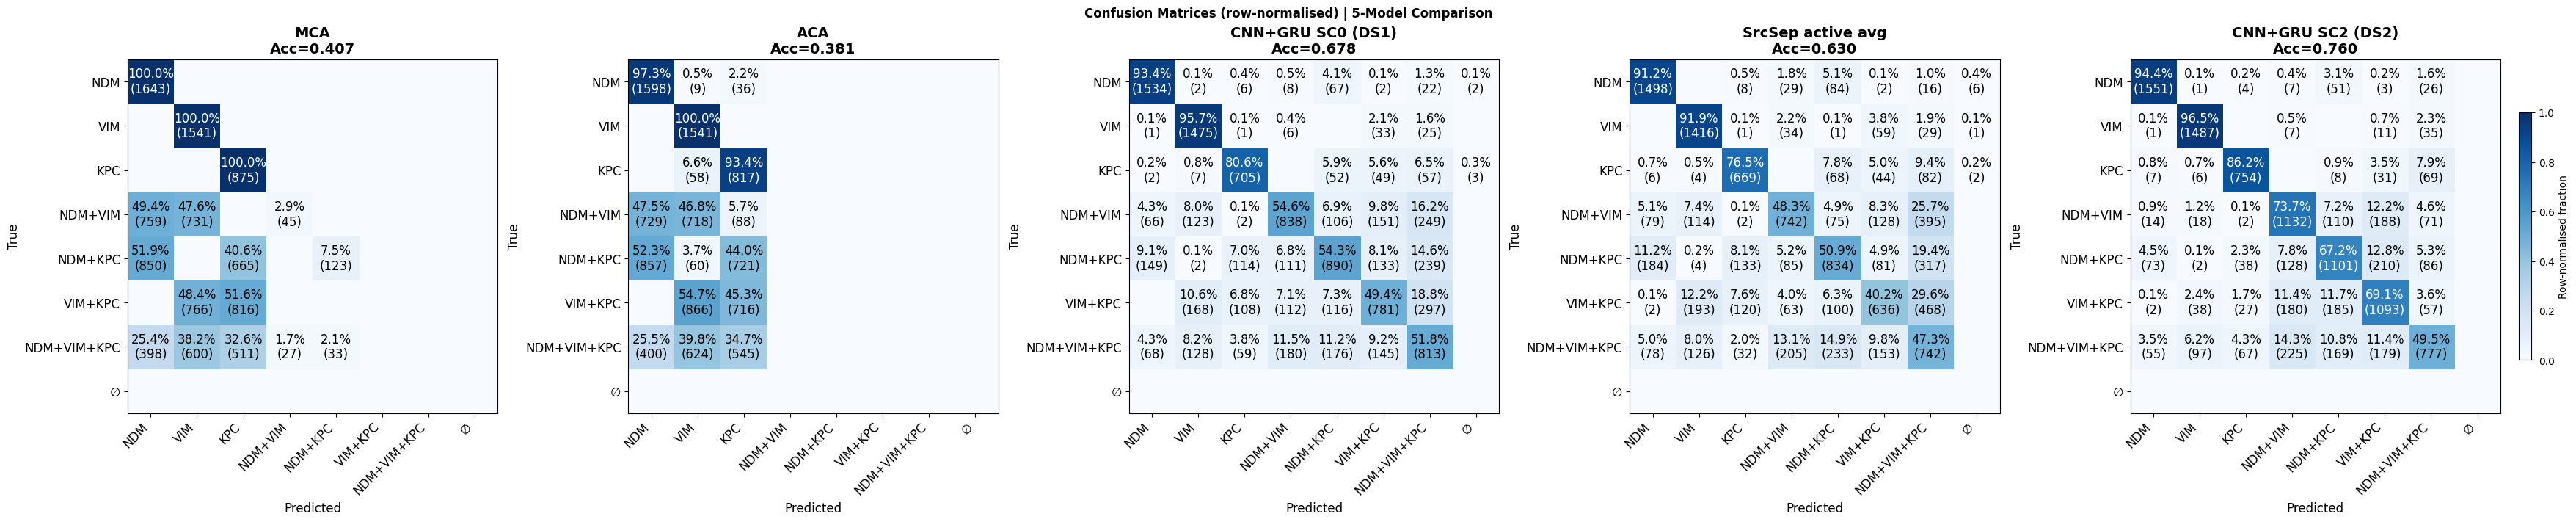

In [8]:
cm_mca = build_cm(yt_mca, yp_mca)
cm_aca = build_cm(yt_aca, yp_aca)

# CNN+GRU SC0 (DS1) — pool folds
yt_d1_all = np.concatenate([np.array(yt) for yt in y_trues_d1])
yp_cgd_sc0 = np.concatenate([np.array(yp) for yp in d1_main['y_preds_cnn_gru_dual_']])
cm_cgd_sc0 = build_cm(yt_d1_all, yp_cgd_sc0)

# Serial source-sep active avg (DS1) — pool folds
yp_ss_all = np.concatenate([np.array(yp) for yp in d1_serial_ss[f'y_preds_{SS_KEY}_']])
cm_ss = build_cm(yt_d1_all, yp_ss_all)

# DS2 CNN+GRU SC2
yt_ds2_all = np.concatenate([DS2_BIN_MAP[np.array(yt)] for yt in d2['y_trues_']])
yp_ds2_sc2 = np.concatenate([DS2_BIN_MAP[np.array(yp)] for yp in d2['y_preds_AC_cnn_gru_dual_supcon2_']])
cm_ds2_sc2 = build_cm(yt_ds2_all, yp_ds2_sc2)

plot_confusion_matrices(
    [('MCA',                   cm_mca),
     ('ACA',                   cm_aca),
     ('CNN+GRU SC0 (DS1)',     cm_cgd_sc0),
     ('SrcSep active avg',     cm_ss),
     ('CNN+GRU SC2 (DS2)',     cm_ds2_sc2)],
    'Confusion Matrices (row-normalised) | 5-Model Comparison'
)

## Section A — All ML Families (Dataset 1 only)

Multilabel performance across CNN / GRU / Transformer / CNN+GRU / CNN+Trans.

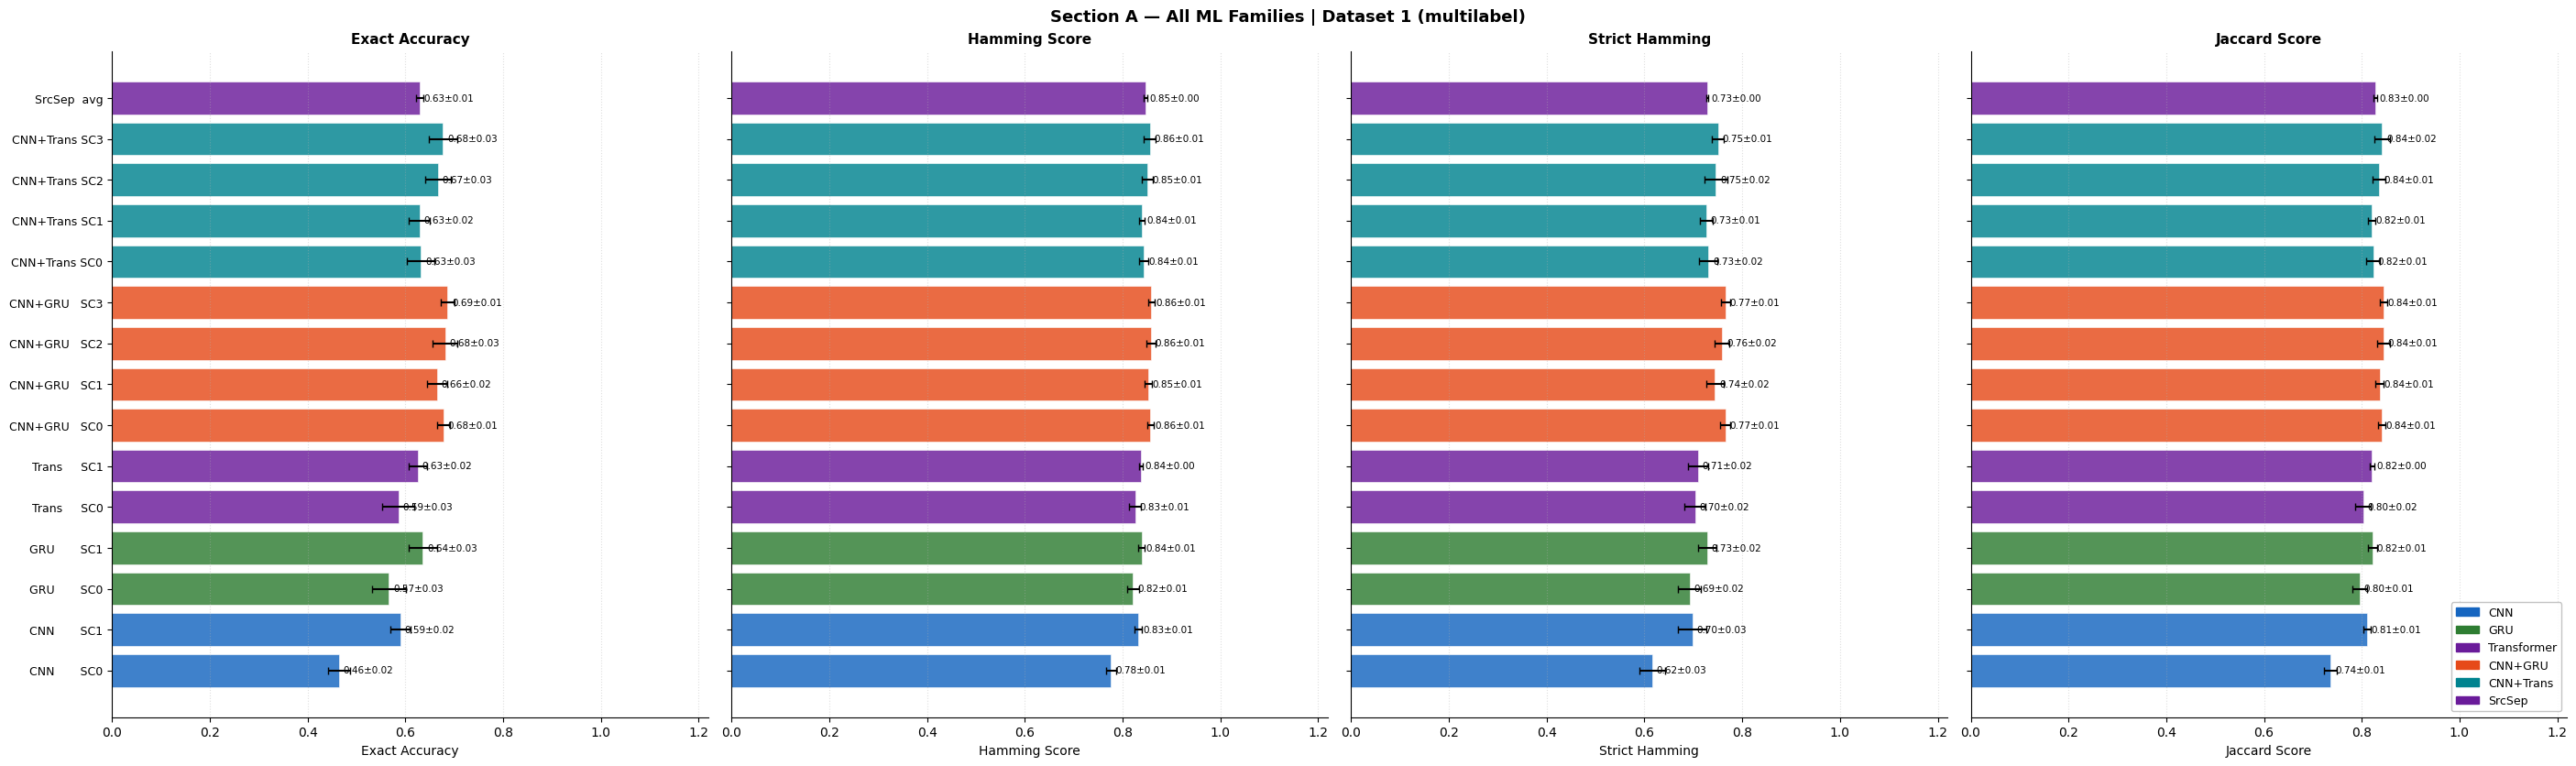

In [9]:
fam_patches = [mpatches.Patch(color=c, label=f) for f, c in FAMILY_COLORS.items()]
plot_metric_bars(
    results_a,
    'Section A — All ML Families | Dataset 1 (multilabel)',
    color_fn=lambda l: FAMILY_COLORS[results_a[l]['family']],
    legend_handles=fam_patches,
)

## Section C — Dataset 1 CNN+GRU Deep Dive

All variants: Base, CRF-MRF, CRF-Chain, CAttn, CAttn-v2.

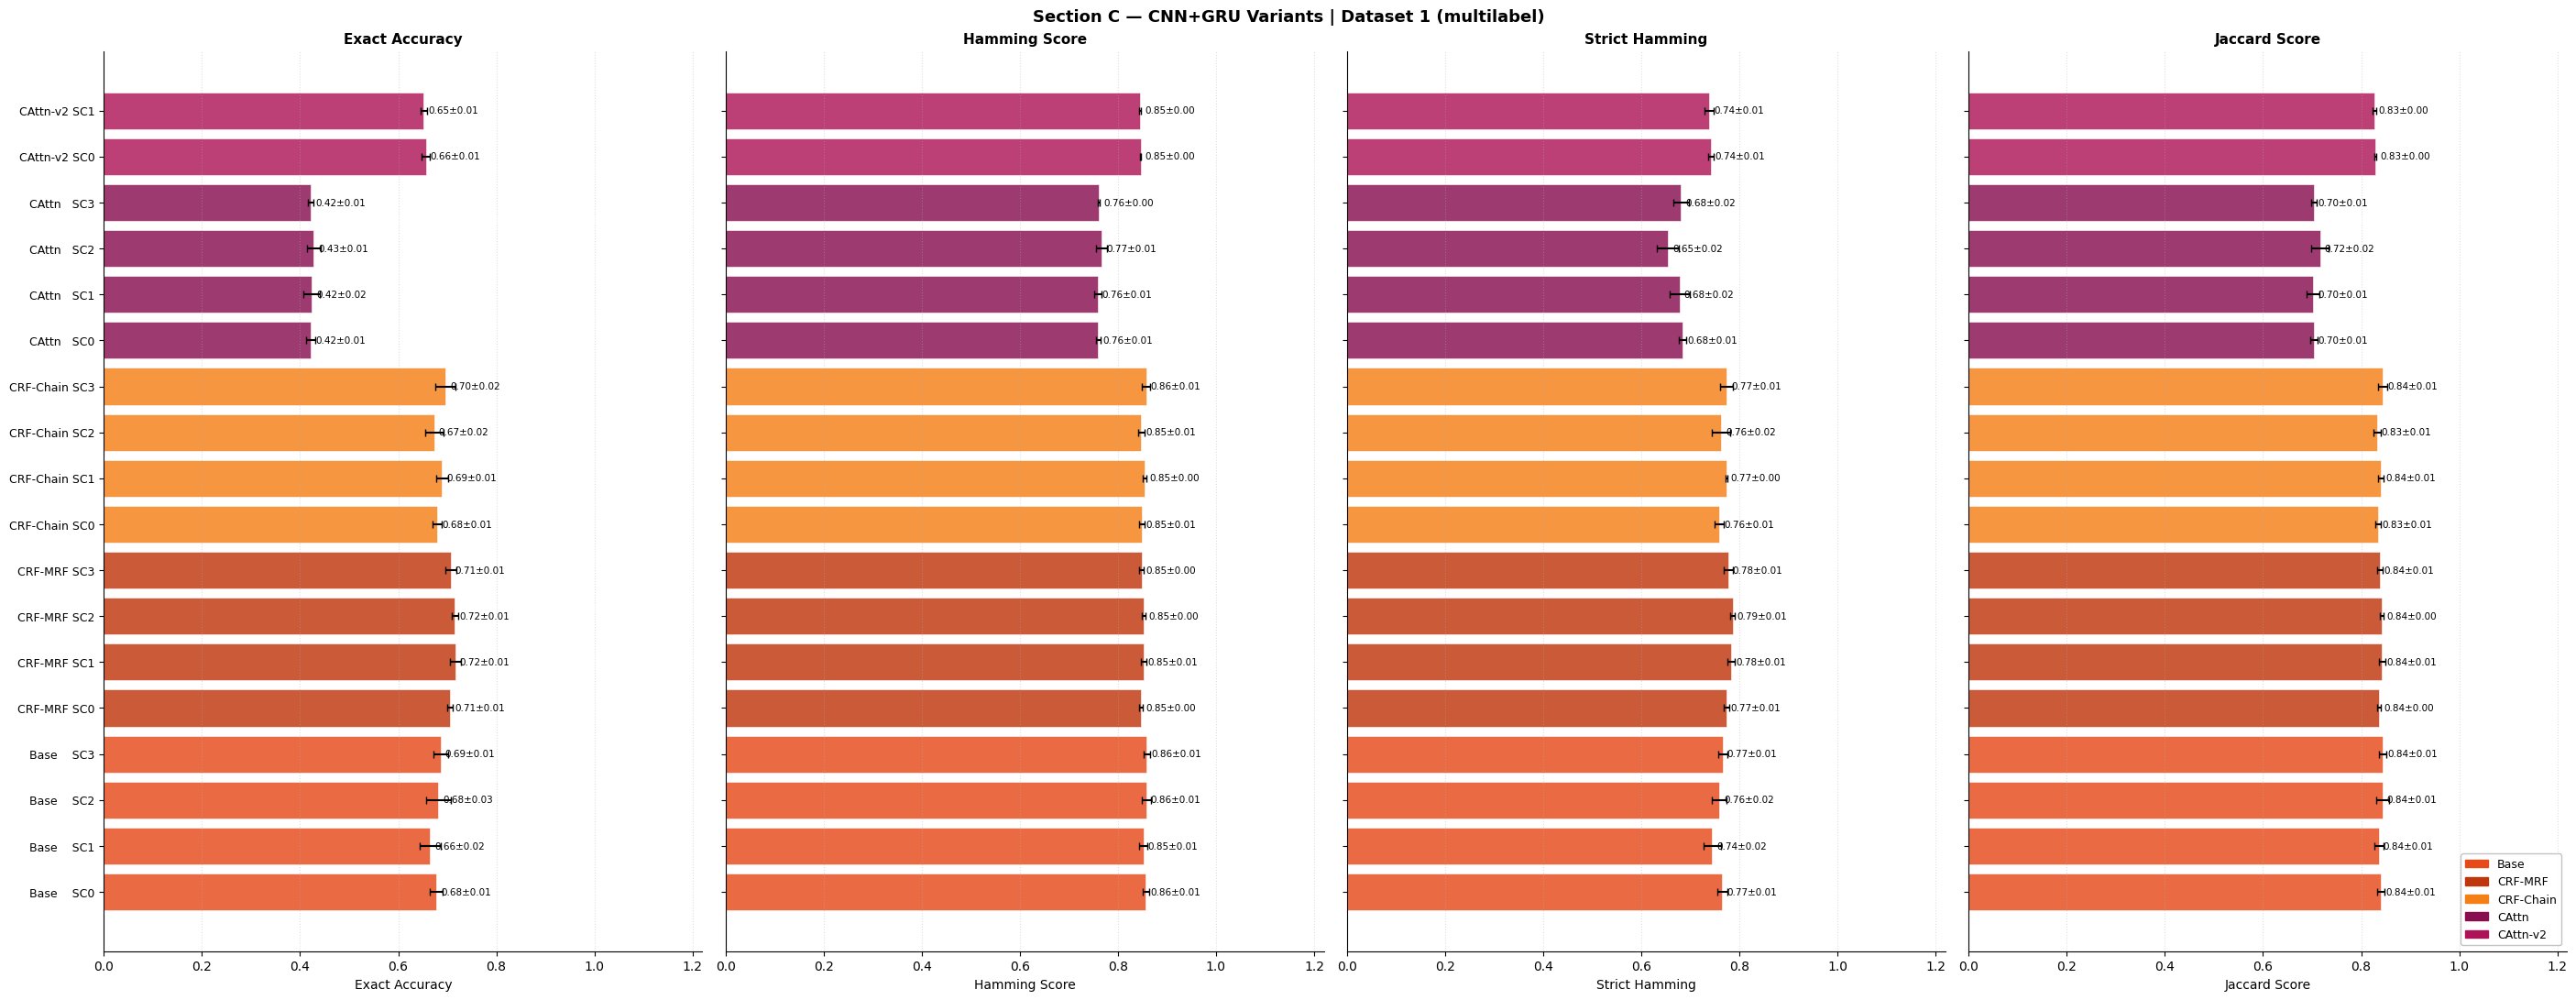

In [10]:
grp_patches = [mpatches.Patch(color=c, label=g) for g, c in GRU_GROUP_COLORS.items()]
plot_metric_bars(
    results_c,
    'Section C — CNN+GRU Variants | Dataset 1 (multilabel)',
    color_fn=lambda l: GRU_GROUP_COLORS[results_c[l]['family']],
    legend_handles=grp_patches,
    row_h=0.6,
)
